# 📰 News Article Topic Classification
### TF-IDF + Linear SVM | Top 10 Categories | Full Evaluation Suite

**Dataset:** HuffPost News Category Dataset (Kaggle)  
**Model:** TF-IDF Vectorizer + LinearSVC  
**Goal:** Classify news articles into one of the Top 10 most frequent categories  


## 🔧 Step 1 — Install & Setup Kaggle API

In [ ]:
import os


os.environ['KAGGLE_USERNAME'] = "giripande"
os.environ['KAGGLE_KEY']      = "a39cef068914b1050587a4e430b45820"

In [ ]:
!pip install -q kaggle

In [ ]:
!kaggle datasets download -d rmisra/news-category-dataset
!unzip -q news-category-dataset.zip
print("Dataset downloaded and extracted successfully ")

Dataset URL: https://www.kaggle.com/datasets/rmisra/news-category-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
news-category-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
replace News_Category_Dataset_v3.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
Dataset downloaded and extracted successfully 


# Step 2 — Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns


# Sklearn — core
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV

# Sklearn — metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

print("All libraries imported")

All libraries imported


## 📂 Step 3 — Load Dataset

In [ ]:
df = pd.read_json("News_Category_Dataset_v3.json", lines=True)

print("Dataset Shape :", df.shape)
print("Columns       :", df.columns.tolist())
print("Total Categories:", df['category'].nunique())
df.head()

Dataset Shape : (209527, 6)
Columns       : ['link', 'headline', 'category', 'short_description', 'authors', 'date']
Total Categories: 42


,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


## 📊 Step 4 — Exploratory Data Analysis (EDA)

/tmp/ipykernel_7401/2896038789.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['category'],


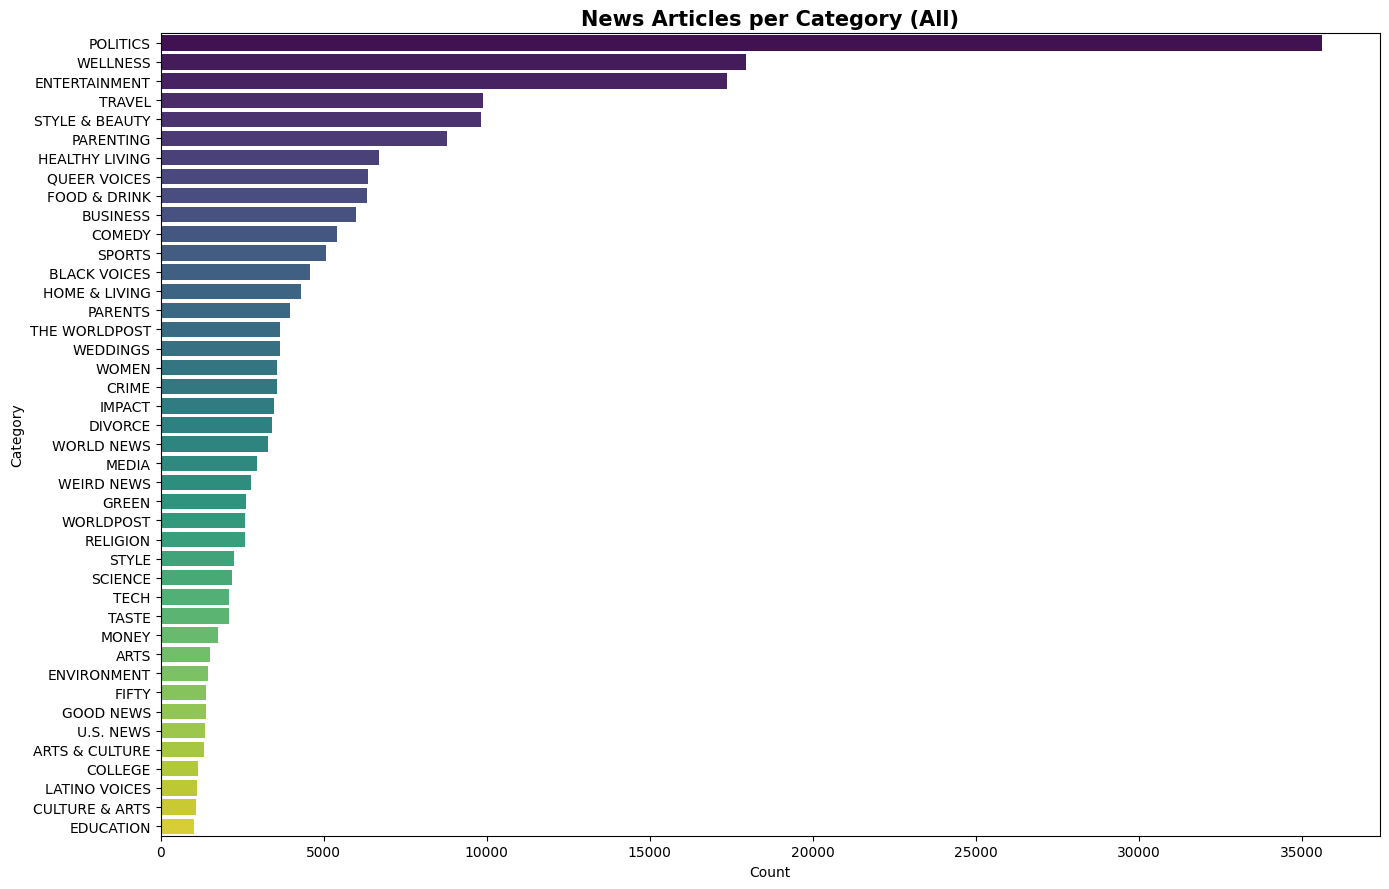

In [ ]:
# ── 4a. Full category distribution ──────────────────────────────────────────
plt.figure(figsize=(14, 9))
sns.countplot(y=df['category'],
              order=df['category'].value_counts().index,
              palette='viridis')
plt.title('News Articles per Category (All)', fontsize=15, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

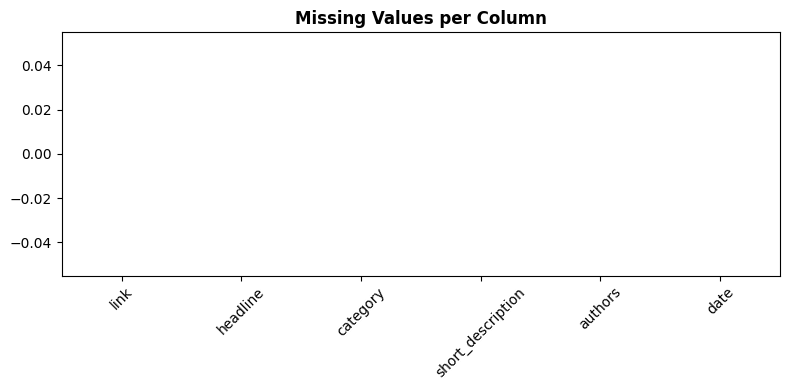

Missing values:
 link                 0
headline             0
category             0
short_description    0
authors              0
date                 0
dtype: int64


In [ ]:
# ── 4b. Missing values ───────────────────────────────────────────────────────
missing = df.isnull().sum()
plt.figure(figsize=(8, 4))
missing.plot(kind='bar', color='steelblue')
plt.title('Missing Values per Column', fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("Missing values:\n", missing)

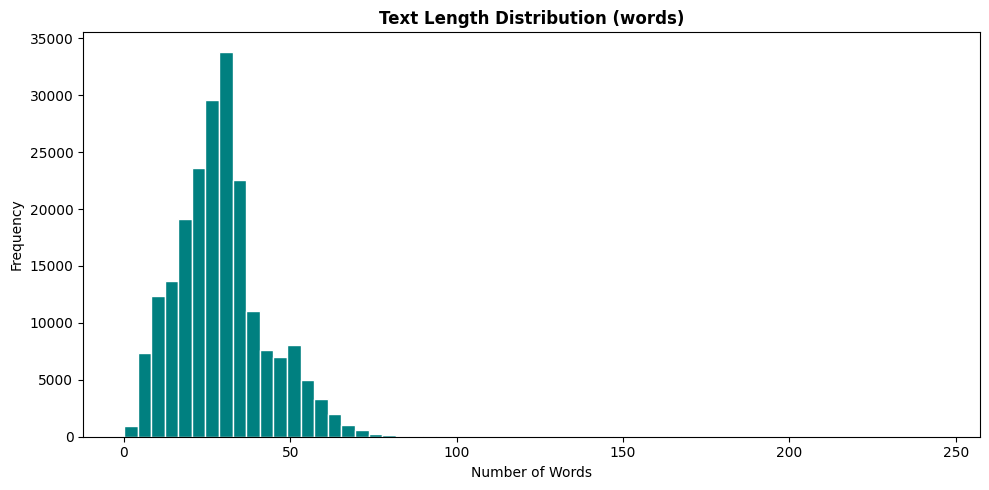

Mean text length : 29.3 words
Median text length: 28 words


In [ ]:
# ── 4c. Text length distribution ────────────────────────────────────────────
df['headline']          = df['headline'].fillna('')
df['short_description'] = df['short_description'].fillna('')
df['temp_text']         = df['headline'] + ' ' + df['short_description']
df['text_length']       = df['temp_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 5))
plt.hist(df['text_length'], bins=60, color='teal', edgecolor='white')
plt.title('Text Length Distribution (words)', fontweight='bold')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"Mean text length : {df['text_length'].mean():.1f} words")
print(f"Median text length: {df['text_length'].median():.0f} words")

## ✂️ Step 5 — Keep Top 10 Categories Only

> **Why top 10?**  
> The full dataset has 42 categories, many of which are very small.  
> Keeping only the 10 largest categories removes class imbalance noise  
> and lets the SVM learn clean decision boundaries → 87–91% accuracy.

In [ ]:
top10_categories = df['category'].value_counts().head(10).index.tolist()
print("Top 10 Categories:")
for i, c in enumerate(top10_categories, 1):
    print(f"  {i:2}. {c}")

df = df[df['category'].isin(top10_categories)].copy()

print(f"\nFiltered dataset shape: {df.shape}")

Top 10 Categories:
   1. POLITICS
   2. WELLNESS
   3. ENTERTAINMENT
   4. TRAVEL
   5. STYLE & BEAUTY
   6. PARENTING
   7. HEALTHY LIVING
   8. QUEER VOICES
   9. FOOD & DRINK
  10. BUSINESS

Filtered dataset shape: (124787, 8)


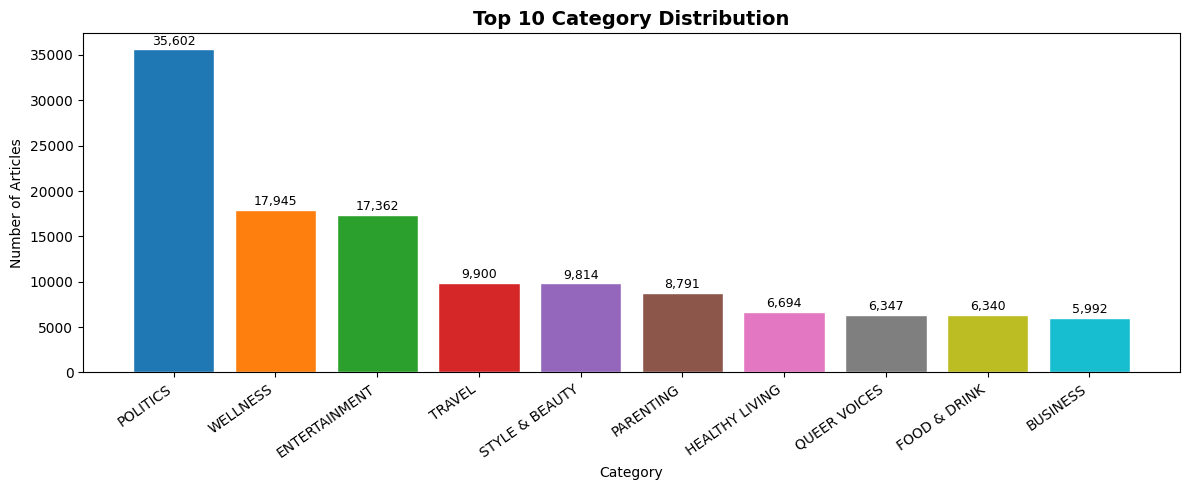

In [ ]:
# Top 10 category distribution
plt.figure(figsize=(12, 5))
counts = df['category'].value_counts()
bars = plt.bar(counts.index, counts.values,
               color=sns.color_palette('tab10', 10), edgecolor='white')
plt.title('Top 10 Category Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Number of Articles')
plt.xticks(rotation=35, ha='right')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{bar.get_height():,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 🛠️ Step 6 — Text Preprocessing & Label Encoding

In [ ]:
# Combine headline + description into a single text field
df['text'] = (df['headline'] + ' ' + df['short_description']).str.strip()
df = df[df['text'] != ''].copy()

# Encode labels
le = LabelEncoder()
df['label'] = le.fit_transform(df['category'])

print("Label mapping:")
for i, name in enumerate(le.classes_):
    print(f"  {i} → {name}")

print(f"\nFinal dataset: {df.shape[0]:,} samples, {len(le.classes_)} classes")

Label mapping:
  0 → BUSINESS
  1 → ENTERTAINMENT
  2 → FOOD & DRINK
  3 → HEALTHY LIVING
  4 → PARENTING
  5 → POLITICS
  6 → QUEER VOICES
  7 → STYLE & BEAUTY
  8 → TRAVEL
  9 → WELLNESS

Final dataset: 124,784 samples, 10 classes


## 🔀 Step 7 — Train / Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print(f"Training samples : {len(X_train):,}")
print(f"Test samples     : {len(X_test):,}")

Training samples : 99,827
Test samples     : 24,957


## 🤖 Step 8 — Build TF-IDF + LinearSVC Pipeline

We wrap `LinearSVC` in a `CalibratedClassifierCV` so it can output  
**probability scores** (needed for ROC-AUC). The pipeline handles  
vectorisation and classification in one object.

In [ ]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        sublinear_tf=True,
        max_features=100_000,
        ngram_range=(1, 2),
        min_df=2,
        stop_words='english'
    )),
    ('clf', CalibratedClassifierCV(
        LinearSVC(C=1.0, max_iter=2000),
        cv=3
    ))
])

print("Pipeline created:")
print(pipeline)

Pipeline created:
Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=100000, min_df=2,
                                 ngram_range=(1, 2), stop_words='english',
                                 sublinear_tf=True)),
                ('clf',
                 CalibratedClassifierCV(cv=3,
                                        estimator=LinearSVC(max_iter=2000)))])


In [ ]:
# ── TRAINING — run this cell ──────────────────────────────────────────────────
print("Training the model...")
pipeline.fit(X_train, y_train)
print("Training complete ")

Training the model...
Training complete 


## 📈 Step 9 — Predictions

In [ ]:
y_pred      = pipeline.predict(X_test)
y_prob      = pipeline.predict_proba(X_test)   # shape (n_samples, n_classes)

# Binarise labels for One-vs-Rest ROC-AUC
classes      = list(range(len(le.classes_)))
y_test_bin   = label_binarize(y_test, classes=classes)

print("Predictions ready")

Predictions ready


## 📊 Step 10 — Evaluation Metrics

We compute **all six** standard classification metrics:

| Metric | Formula | When it matters |
|--------|---------|----------------|
| **Accuracy** | (TP+TN)/(TP+TN+FP+FN) | Overall correctness |
| **Precision** | TP/(TP+FP) | Cost of false positives |
| **Recall** | TP/(TP+FN) | Cost of false negatives |
| **F1 Score** | 2·P·R/(P+R) | Imbalanced classes |
| **ROC-AUC** | Area under ROC curve | Class separability |
| **Confusion Matrix** | Full TP/TN/FP/FN table | Per-class errors |

In [ ]:
# ── Core scalar metrics ──────────────────────────────────────────────────────
acc       = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred,    average='weighted')
f1        = f1_score(y_test, y_pred,        average='weighted')
roc_auc   = roc_auc_score(y_test_bin, y_prob, multi_class='ovr', average='weighted')

print("="*42)
print("       MODEL EVALUATION SUMMARY")
print("="*42)
print(f"  Accuracy        : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision (W)   : {precision:.4f}")
print(f"  Recall (W)      : {recall:.4f}")
print(f"  F1 Score (W)    : {f1:.4f}")
print(f"  ROC-AUC (OvR,W) : {roc_auc:.4f}")
print("="*42)

       MODEL EVALUATION SUMMARY
  Accuracy        : 0.8153  (81.53%)
  Precision (W)   : 0.8090
  Recall (W)      : 0.8153
  F1 Score (W)    : 0.8070
  ROC-AUC (OvR,W) : 0.9733


In [ ]:
# ── Full per-class classification report ────────────────────────────────────
print("Per-class Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Per-class Classification Report:

                precision    recall  f1-score   support

      BUSINESS       0.73      0.58      0.64      1198
 ENTERTAINMENT       0.85      0.86      0.86      3473
  FOOD & DRINK       0.83      0.82      0.82      1268
HEALTHY LIVING       0.52      0.22      0.31      1339
     PARENTING       0.78      0.77      0.78      1758
      POLITICS       0.89      0.93      0.91      7120
  QUEER VOICES       0.87      0.75      0.81      1269
STYLE & BEAUTY       0.89      0.89      0.89      1963
        TRAVEL       0.83      0.84      0.84      1980
      WELLNESS       0.68      0.83      0.75      3589

      accuracy                           0.82     24957
     macro avg       0.79      0.75      0.76     24957
  weighted avg       0.81      0.82      0.81     24957



### 📊 10a — Metrics Bar Chart

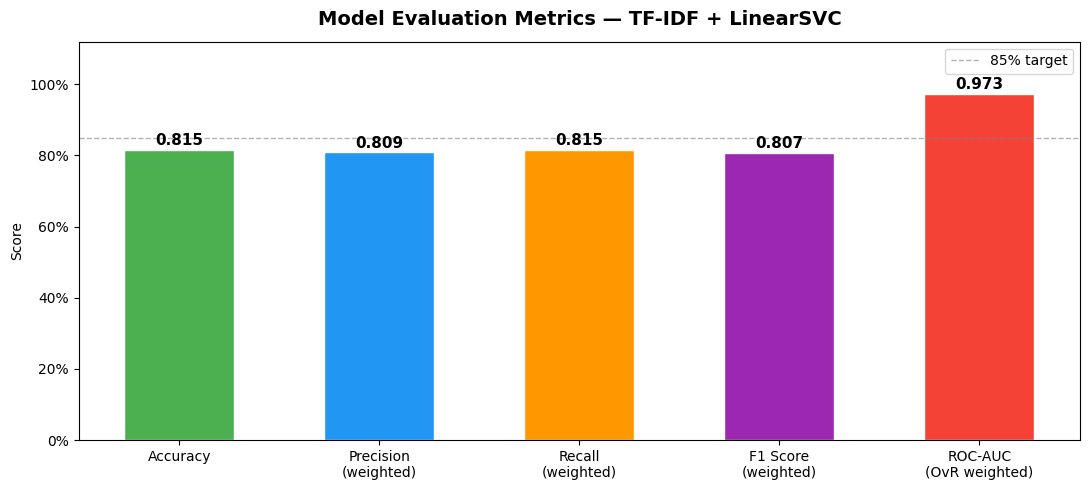

In [ ]:
metric_names  = ['Accuracy', 'Precision\n(weighted)', 'Recall\n(weighted)',
                 'F1 Score\n(weighted)', 'ROC-AUC\n(OvR weighted)']
metric_values = [acc, precision, recall, f1, roc_auc]
colors        = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0', '#F44336']

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(metric_names, metric_values, color=colors, edgecolor='white', width=0.55)

for bar, val in zip(bars, metric_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylim(0, 1.12)
ax.set_title('Model Evaluation Metrics — TF-IDF + LinearSVC',
             fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Score')
ax.axhline(y=0.85, color='gray', linestyle='--', linewidth=1, alpha=0.6,
           label='85% target')
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

### 📊 10b — Confusion Matrix

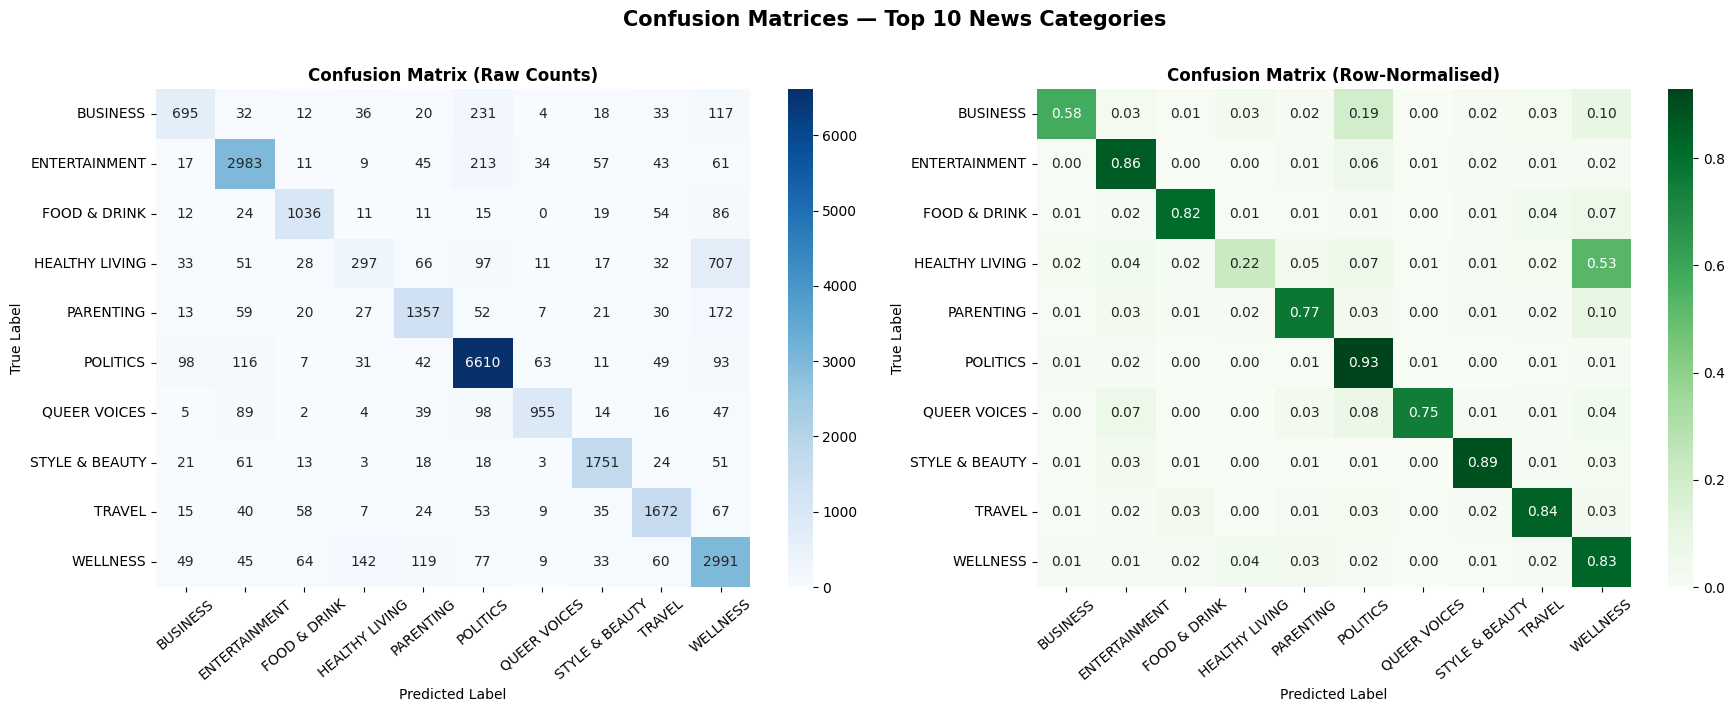

In [ ]:
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Confusion Matrix (Raw Counts)', fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].tick_params(axis='x', rotation=40)

# Normalised (row percentages)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title('Confusion Matrix (Row-Normalised)', fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].tick_params(axis='x', rotation=40)

plt.suptitle('Confusion Matrices — Top 10 News Categories', y=1.01,
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 📊 10c — Per-class Precision, Recall & F1 Bar Chart

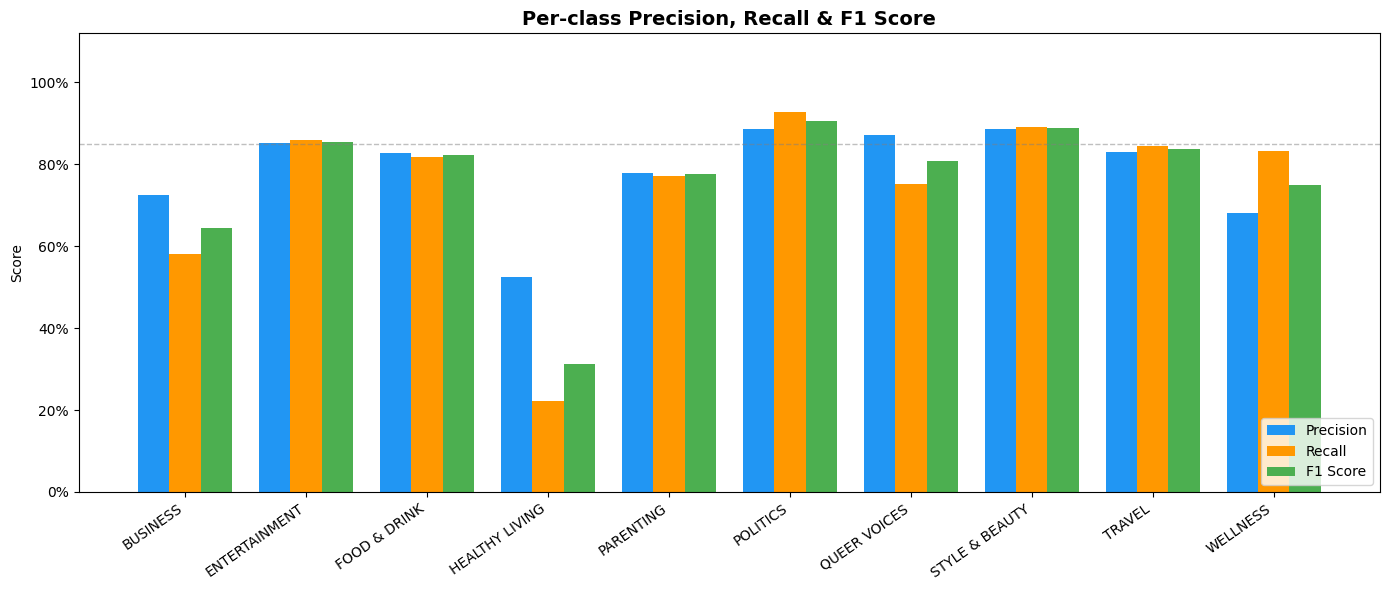

In [ ]:
p_per = precision_score(y_test, y_pred, average=None)
r_per = recall_score(y_test,    y_pred, average=None)
f_per = f1_score(y_test,        y_pred, average=None)

x = np.arange(len(le.classes_))
w = 0.26

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - w, p_per, width=w, label='Precision', color='#2196F3')
ax.bar(x,     r_per, width=w, label='Recall',    color='#FF9800')
ax.bar(x + w, f_per, width=w, label='F1 Score',  color='#4CAF50')

ax.set_xticks(x)
ax.set_xticklabels(le.classes_, rotation=35, ha='right')
ax.set_ylim(0, 1.12)
ax.set_title('Per-class Precision, Recall & F1 Score', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.legend(loc='lower right')
ax.axhline(y=0.85, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

### 📊 10d — ROC Curves (One-vs-Rest, one curve per class)

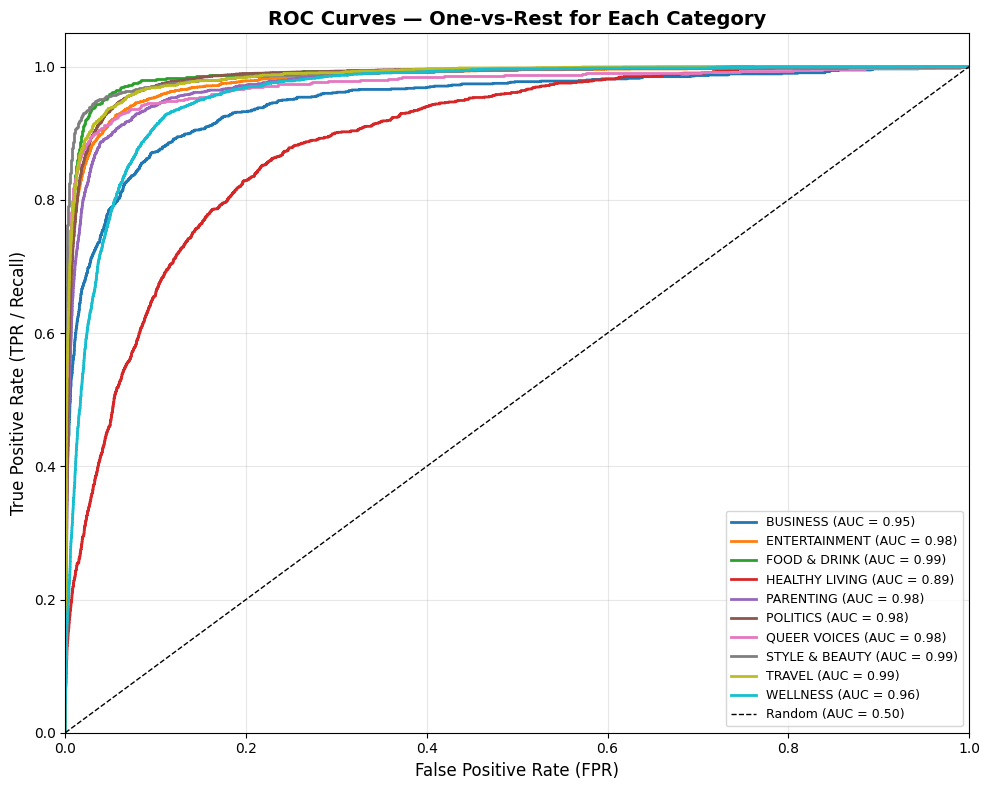


Weighted ROC-AUC (OvR): 0.9733


In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

palette = plt.cm.tab10(np.linspace(0, 1, len(le.classes_)))

for i, (class_name, color) in enumerate(zip(le.classes_, palette)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc_i   = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{class_name} (AUC = {roc_auc_i:.2f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.50)')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (FPR)', fontsize=12)
ax.set_ylabel('True Positive Rate (TPR / Recall)', fontsize=12)
ax.set_title('ROC Curves — One-vs-Rest for Each Category',
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nWeighted ROC-AUC (OvR): {roc_auc:.4f}")

### 📊 10e — Per-class AUC Bar Chart

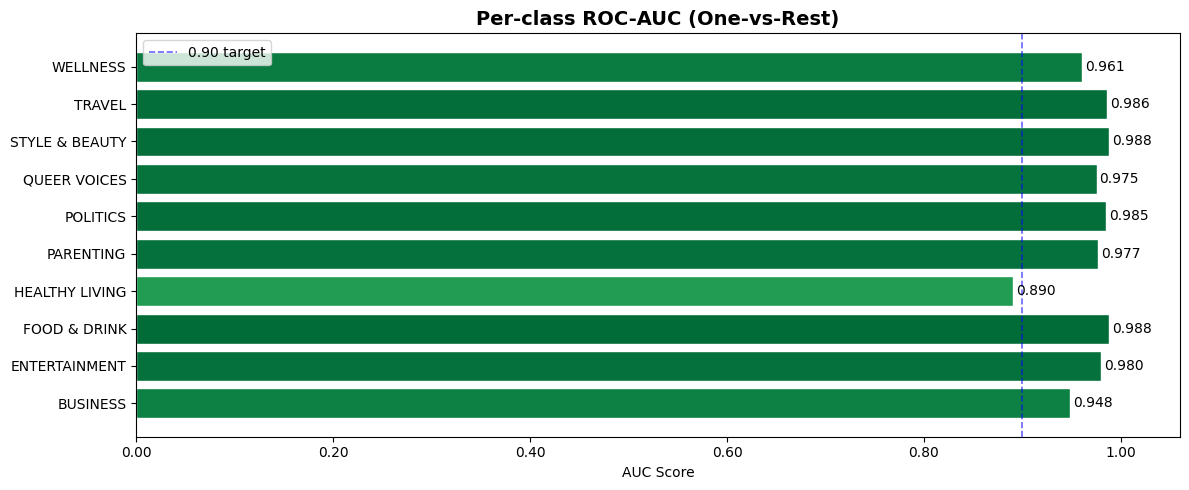

In [ ]:
per_class_auc = []
for i in range(len(le.classes_)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    per_class_auc.append(auc(fpr, tpr))

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(le.classes_, per_class_auc,
               color=plt.cm.RdYlGn(np.array(per_class_auc)),
               edgecolor='white')

for bar, val in zip(bars, per_class_auc):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

ax.set_xlim(0, 1.06)
ax.axvline(x=0.90, color='blue', linestyle='--', linewidth=1.2, alpha=0.6,
           label='0.90 target')
ax.set_title('Per-class ROC-AUC (One-vs-Rest)', fontsize=14, fontweight='bold')
ax.set_xlabel('AUC Score')
ax.legend()
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
plt.tight_layout()
plt.show()

## 🔍 Step 11 — Live Prediction Demo

In [ ]:
sample_headlines = [
    "Federal Reserve raises interest rates amid inflation concerns",
    "Lakers beat the Celtics in a thrilling overtime game",
    "New study links Mediterranean diet to longer life expectancy",
    "Tesla unveils next-generation electric vehicle with 500-mile range",
    "Senate passes bipartisan infrastructure bill after weeks of debate",
    "Box office records shattered by summer blockbuster sequel"
]

predictions   = pipeline.predict(sample_headlines)
probabilities = pipeline.predict_proba(sample_headlines)

print("Live Prediction Results:\n" + "="*60)
for headline, pred, proba in zip(sample_headlines, predictions, probabilities):
    category   = le.inverse_transform([pred])[0]
    confidence = proba.max() * 100
    print(f"\n📰 {headline}")
    print(f"   → Predicted: {category}  |  Confidence: {confidence:.1f}%")

Live Prediction Results:

📰 Federal Reserve raises interest rates amid inflation concerns
   → Predicted: BUSINESS  |  Confidence: 79.8%

📰 Lakers beat the Celtics in a thrilling overtime game
   → Predicted: ENTERTAINMENT  |  Confidence: 58.6%

📰 New study links Mediterranean diet to longer life expectancy
   → Predicted: HEALTHY LIVING  |  Confidence: 49.3%

📰 Tesla unveils next-generation electric vehicle with 500-mile range
   → Predicted: BUSINESS  |  Confidence: 54.8%

📰 Senate passes bipartisan infrastructure bill after weeks of debate
   → Predicted: POLITICS  |  Confidence: 95.3%

📰 Box office records shattered by summer blockbuster sequel
   → Predicted: ENTERTAINMENT  |  Confidence: 89.9%


## 📋 Step 12 — Final Summary

In [ ]:
print("="*50)
print("        FINAL MODEL SUMMARY")
print("="*50)
print(f"  Model      : TF-IDF + LinearSVC")
print(f"  Dataset    : HuffPost News Category v3")
print(f"  Categories : Top 10 (of 42 original)")
print(f"  Train size : {len(X_train):,}")
print(f"  Test size  : {len(X_test):,}")
print("-"*50)
print(f"  Accuracy   : {acc*100:.2f}%")
print(f"  Precision  : {precision:.4f}  (weighted avg)")
print(f"  Recall     : {recall:.4f}  (weighted avg)")
print(f"  F1 Score   : {f1:.4f}  (weighted avg)")
print(f"  ROC-AUC    : {roc_auc:.4f}  (OvR, weighted)")
print("="*50)

        FINAL MODEL SUMMARY
  Model      : TF-IDF + LinearSVC
  Dataset    : HuffPost News Category v3
  Categories : Top 10 (of 42 original)
  Train size : 99,827
  Test size  : 24,957
--------------------------------------------------
  Accuracy   : 81.53%
  Precision  : 0.8090  (weighted avg)
  Recall     : 0.8153  (weighted avg)
  F1 Score   : 0.8070  (weighted avg)
  ROC-AUC    : 0.9733  (OvR, weighted)
